# Universe method

by Reece Colclough and Oleg Glotov

In [205]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sbn

#used to check for stationarity in the time series
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import linregress

# ignore warnings for the KPSS test 
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

In order to find the best stationarity pair, we need to utilize both the ADF test and the KPSS test. Both tests have their drawback and potential issue, therefore, a pair of stocks that performs well in both tests are likely to be more stationary. We construct this test statistic in the following way:
$$\text{Stationarity Score} = - \text{KPSS Stats} - \text{ADF Test}$$
since a low KPSS stats and a low ADF stats both indicates stronger evidence of stationarity (how we weight these two stats is subjective to improvement)

In [206]:
def check_stationarity(series, alpha):

    # h_0 is that the series has a unit root-> if so, likely non-stationarity
    result_adf = adfuller(series,regression='ct')
    p_val = result_adf[1]
    if p_val < alpha:
        # reject, likely trend stationary
        print("ADF test: p-val=", p_val, "-> Conclusion: likely trend stationary")
    else:
        print("ADF test: p-val=", p_val, "-> Conclusion: likely non-stationarity")

    #return result_adf[1]

     #print("----------------------------------------------------------------")
    
    # Since we are focusing on the trend stationarity, we will use the KPSS test
    result_kpss = kpss(series, regression='ct')
    kpss_stat = result_kpss[0]
    p_val = result_kpss[1]
    if p_val > alpha:
        #reject, likely stationary
        print("KPSS test: KPSS stats:", kpss_stat, "p-val=", p_val, "-> Conclusion: likely trend stationary")
    else:
        print("KPSS test: KPSS stats:", kpss_stat, "p-val=", p_val, "-> Conclusion: likely not trend stationary")
    
    station_score = -kpss_stat - result_adf[0]
    return station_score


In [207]:
def methodology_cointegration(stk1, stk2):
    diff = abs(stk1["Adj Close"] - stk2["Adj Close"])

    time = np.arange(len(diff))
    reg = linregress(time, diff)
    #line = reg.intercept + reg.slope*time
    #new_series = diff - line

    return check_stationarity(diff, 0.05), reg.slope


def methodology(stk1, stk2):
    # Calculate correlation between the two stocks' adjusted close prices
    correlation = np.corrcoef(stk1["Adj Close"], stk2["Adj Close"])[0,1]
    
    # Calculate the slope between the two stocks
    time = np.arange(len(stk1["Adj Close"]))
    reg = linregress(time, stk2["Adj Close"] - stk1["Adj Close"])
    
    return correlation, reg.slope

In [208]:
def download_data(stk):

    # start date because of moderna listing in 2018 December and yfinance data delay

    start_date = "2024-01-16"
    end_date = "2025-01-15"

    stk_data = yf.download(stk,start=start_date,end=end_date)

    return stk_data

In [209]:
# Will plot 2 equities

# universe = ["MSFT", "MRNA",]

# stk_data = []
# for stk in universe:
#     stk_data.append(download_data(stk))

# plt.figure()
# for x in stk_data:
#     plt.plot(x["Adj Close"], label="stk1")

# plt.legend()
# plt.title("stks Price Plot")
# plt.show()

In [210]:
# Download Data

# universe = ["AAPL","AAL","AMD","AMZN","BA","BABA","BAC","C","CAT","COST","CSCO","CVX","DIS","DLR","EQIX","F","GM","GOOGL","GS","IBM","INTC","JNJ","JPM","KO","LMT","LULU","META","MPC","MRK","MRNA","MSFT","MU","NFLX","NKE","NVDA","PFE","TSLA","VZ","WFC","WM","XOM","SCHW","RIOT",]

universe = ["^VIX", "LNF.TO", "TGT", "ANET", "BLDR", "EQT", "TLT", "GC=F", "HG=F", "CL=F", "NKE", "^GSPTSE" , "CADUSD=X", "^TNX"]

stk_data = []
for stk in universe:
    stk_data.append(download_data(stk))

# Align all dataframes on their index
aligned_data = []
for df in stk_data:
    # Reset index to make date a column
    df_reset = df.reset_index()
    aligned_data.append(df_reset)

# Find common dates across all dataframes
common_dates = set(aligned_data[0]['Date'])
for df in aligned_data[1:]:
    common_dates = common_dates.intersection(set(df['Date']))

# Filter each dataframe to only include common dates
filtered_data = []
for df in aligned_data:
    filtered = df[df['Date'].isin(common_dates)].sort_values('Date').set_index('Date')
    filtered_data.append(filtered)

stk_data = filtered_data  # Replace original data with aligned data

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [211]:
for stk in stk_data:
    print(stk)

                 Open       High        Low      Close  Adj Close  Volume
Date                                                                     
2024-01-16  14.120000  14.350000  13.520000  13.840000  13.840000       0
2024-01-17  14.590000  15.400000  14.380000  14.790000  14.790000       0
2024-01-18  14.850000  14.890000  13.890000  14.130000  14.130000       0
2024-01-19  13.800000  14.580000  13.280000  13.300000  13.300000       0
2024-01-22  13.770000  13.840000  13.170000  13.190000  13.190000       0
...               ...        ...        ...        ...        ...     ...
2025-01-07  16.480000  18.900000  15.790000  17.820000  17.820000       0
2025-01-08  17.910000  19.500000  17.370001  17.700001  17.700001       0
2025-01-10  18.290001  20.309999  18.049999  19.540001  19.540001       0
2025-01-13  21.180000  22.040001  19.150000  19.190001  19.190001       0
2025-01-14  18.790001  19.660000  18.240000  18.709999  18.709999       0

[246 rows x 6 columns]
              

In [212]:
# normalize the stock price for all the stocks so that the first date's price is 1

for i in range(len(stk_data)):
    stk_data[i]["Adj Close"] = stk_data[i]["Adj Close"]/stk_data[i]["Adj Close"][0]

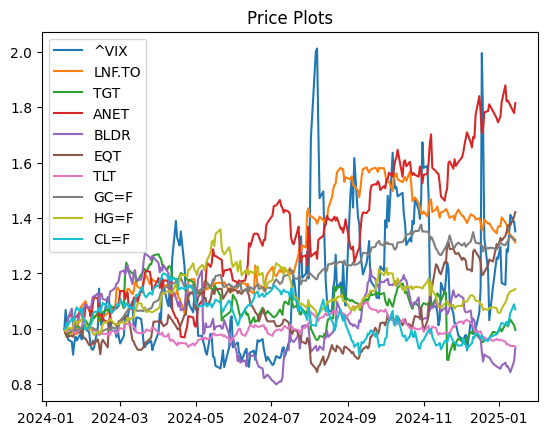

In [213]:
plt.figure()
i = 0
for x in stk_data[:10]:
    plt.plot(x["Adj Close"], label=universe[i])
    i+=1

plt.legend()
plt.title("Price Plots")
plt.savefig('Stock Prices.png', dpi = 1500)
# plt.show()

In [214]:
# initialize cov-matrix
data = np.random.rand(len(universe), len(universe))
slope = np.random.rand(len(universe), len(universe))
stockNum = len(universe)


# Calculate the stationary properties
cov = np.zeros((stockNum, stockNum))
for i in range(stockNum):
    for j in range(stockNum):
        if (i == j):
            data[i,j] = 1
            # set the slope to 0 if the stock is the same
            slope[i,j] = 0
        else:
            print(universe[i]+universe[j])
            
            data[i,j],slope[i,j] = methodology(stk_data[i],stk_data[j])

^VIXLNF.TO
^VIXTGT
^VIXANET
^VIXBLDR
^VIXEQT
^VIXTLT
^VIXGC=F
^VIXHG=F
^VIXCL=F
^VIXNKE
^VIX^GSPTSE
^VIXCADUSD=X
^VIX^TNX
LNF.TO^VIX
LNF.TOTGT
LNF.TOANET
LNF.TOBLDR
LNF.TOEQT
LNF.TOTLT
LNF.TOGC=F
LNF.TOHG=F
LNF.TOCL=F
LNF.TONKE
LNF.TO^GSPTSE
LNF.TOCADUSD=X
LNF.TO^TNX
TGT^VIX
TGTLNF.TO
TGTANET
TGTBLDR
TGTEQT
TGTTLT
TGTGC=F
TGTHG=F
TGTCL=F
TGTNKE
TGT^GSPTSE
TGTCADUSD=X
TGT^TNX
ANET^VIX
ANETLNF.TO
ANETTGT
ANETBLDR
ANETEQT
ANETTLT
ANETGC=F
ANETHG=F
ANETCL=F
ANETNKE
ANET^GSPTSE
ANETCADUSD=X
ANET^TNX
BLDR^VIX
BLDRLNF.TO
BLDRTGT
BLDRANET
BLDREQT
BLDRTLT
BLDRGC=F
BLDRHG=F
BLDRCL=F
BLDRNKE
BLDR^GSPTSE
BLDRCADUSD=X
BLDR^TNX
EQT^VIX
EQTLNF.TO
EQTTGT
EQTANET
EQTBLDR
EQTTLT
EQTGC=F
EQTHG=F
EQTCL=F
EQTNKE
EQT^GSPTSE
EQTCADUSD=X
EQT^TNX
TLT^VIX
TLTLNF.TO
TLTTGT
TLTANET
TLTBLDR
TLTEQT
TLTGC=F
TLTHG=F
TLTCL=F
TLTNKE
TLT^GSPTSE
TLTCADUSD=X
TLT^TNX
GC=F^VIX
GC=FLNF.TO
GC=FTGT
GC=FANET
GC=FBLDR
GC=FEQT
GC=FTLT
GC=FHG=F
GC=FCL=F
GC=FNKE
GC=F^GSPTSE
GC=FCADUSD=X
GC=F^TNX
HG=F^VIX
HG=FLNF.TO
HG=FTGT
HG=FANET

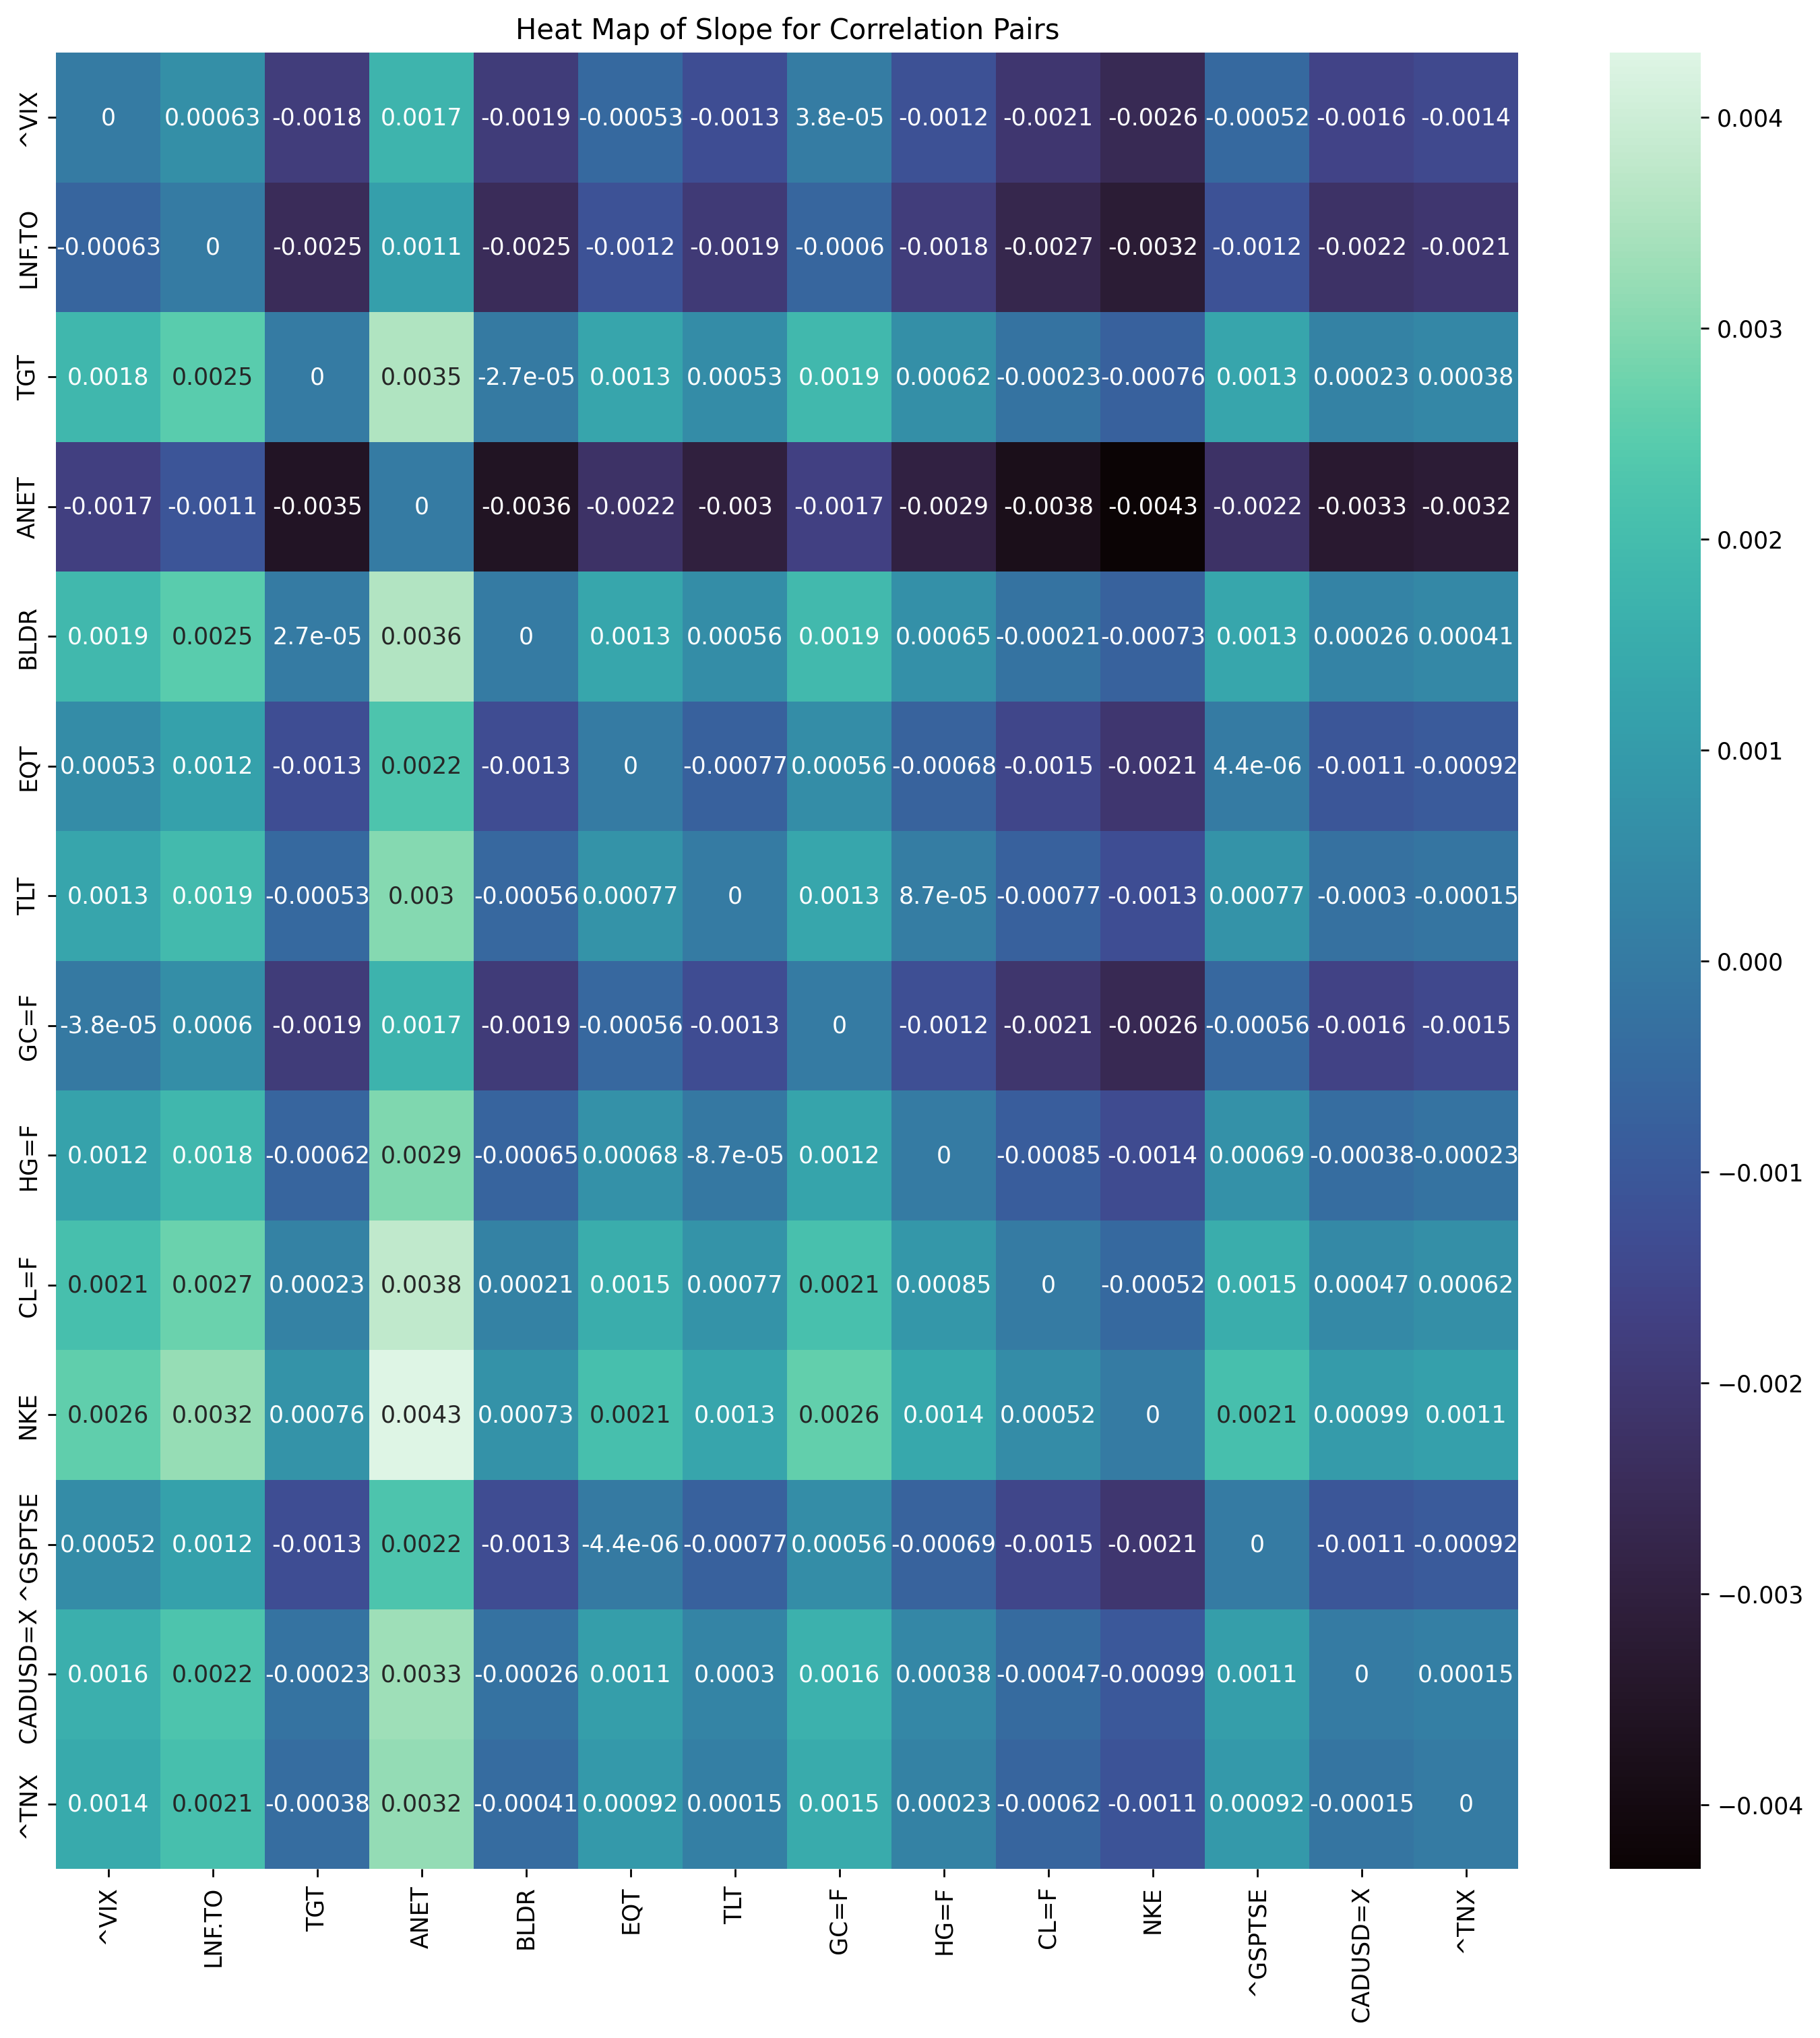

In [215]:
# Create a heatmap of slope using Matplotlib
plt.figure(figsize=(stockNum, stockNum),dpi=250)
heat_map_slope = sbn.heatmap(slope, xticklabels=universe, yticklabels=universe, annot=True, cmap="mako")
plt.title("Heat Map of Slope for Correlation Pairs")

plt.savefig('HeatMap_slope.png')
plt.show()

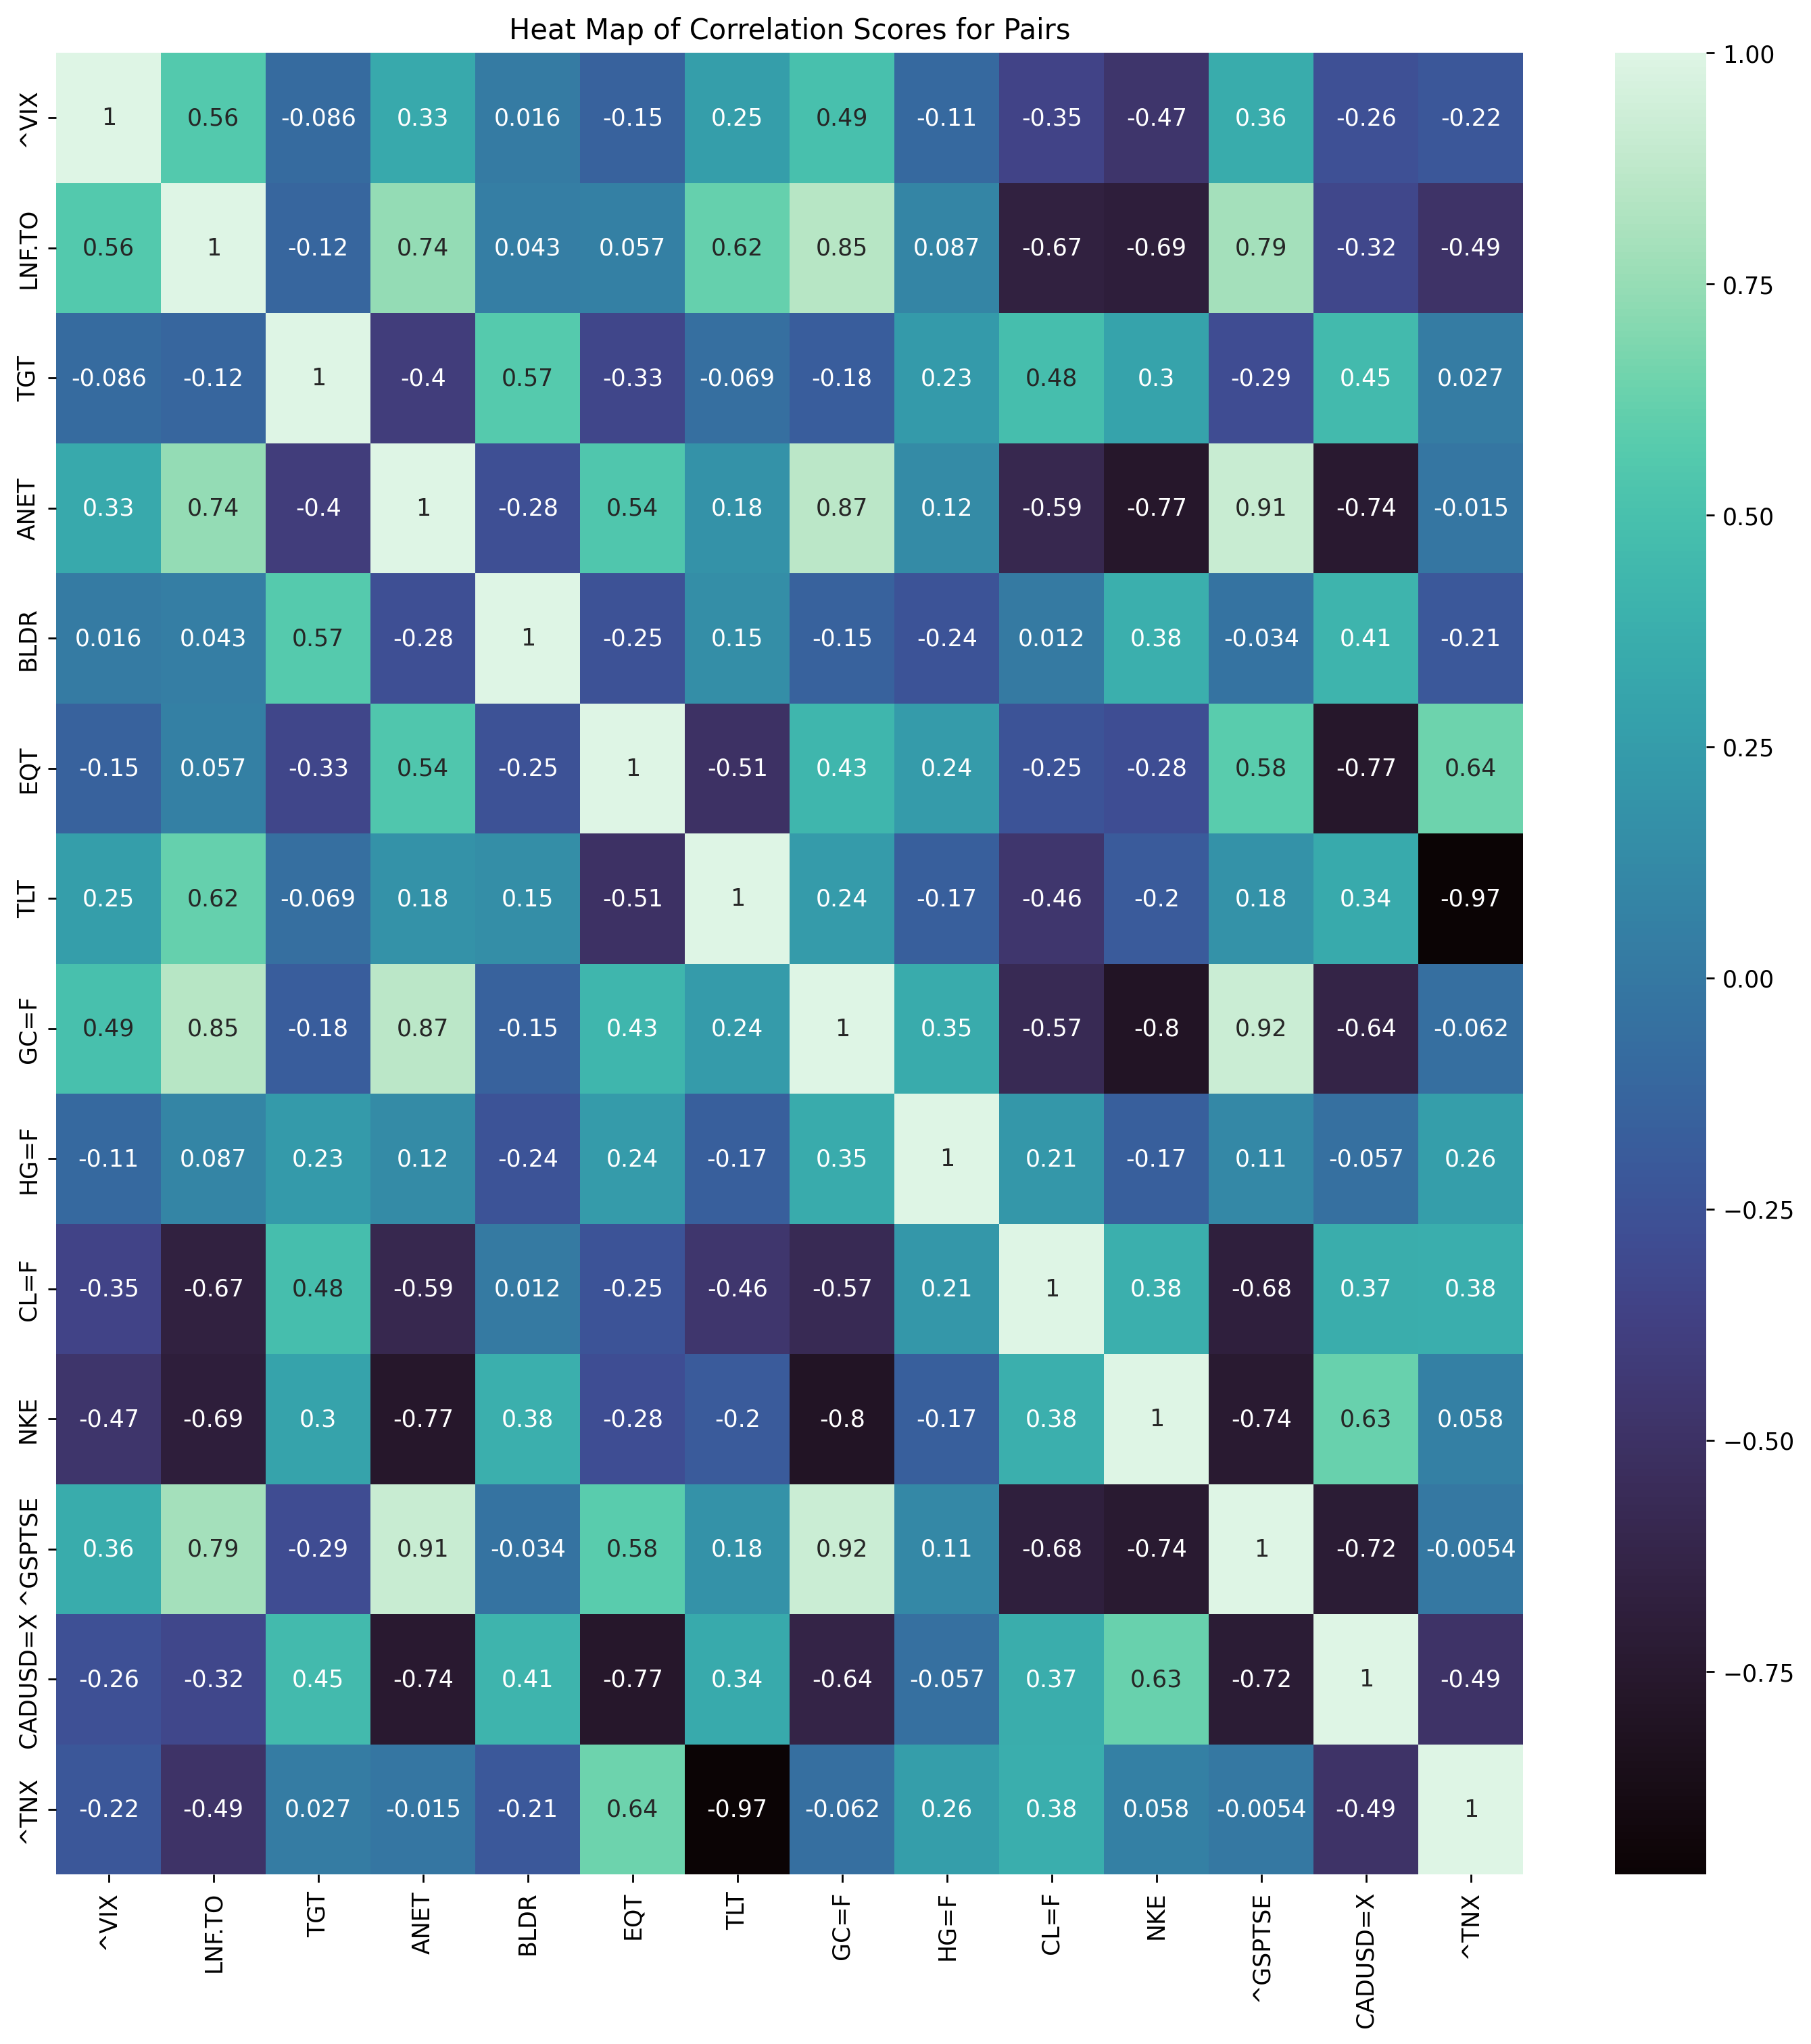

In [216]:
# Create a heatmap using Matplotlib
plt.figure(figsize=(stockNum, stockNum),dpi=250)
heat_map = sbn.heatmap(data, xticklabels=universe, yticklabels=universe, annot=True, cmap="mako")
plt.title("Heat Map of Correlation Scores for Pairs")

plt.savefig('HeatMap_correlation_score.png')
plt.show()

In [217]:
df = pd.DataFrame(data = data)
df.columns = universe

print("Data Frame")
print(df)
print()

# Get data below diagonal and sort
sol = (df.where(np.triu(np.ones(df.shape), k=1).astype(bool)).stack().sort_values(ascending=False).reset_index())

mapping = {i: universe[i] for i in range(len(universe))}

# Replace numbers in column 'A' with the corresponding index string
sol['level_0'] = sol['level_0'].map(mapping)

Data Frame
        ^VIX    LNF.TO       TGT      ANET      BLDR       EQT       TLT  \
0   1.000000  0.559000 -0.086128  0.333994  0.015583 -0.153199  0.253869   
1   0.559000  1.000000 -0.118072  0.741672  0.042877  0.057481  0.618710   
2  -0.086128 -0.118072  1.000000 -0.404361  0.565706 -0.331019 -0.068918   
3   0.333994  0.741672 -0.404361  1.000000 -0.275155  0.544982  0.181332   
4   0.015583  0.042877  0.565706 -0.275155  1.000000 -0.252727  0.150793   
5  -0.153199  0.057481 -0.331019  0.544982 -0.252727  1.000000 -0.507049   
6   0.253869  0.618710 -0.068918  0.181332  0.150793 -0.507049  1.000000   
7   0.494290  0.848429 -0.180975  0.868680 -0.147982  0.426711  0.243271   
8  -0.107402  0.087234  0.231628  0.123972 -0.243596  0.241238 -0.166233   
9  -0.346571 -0.665332  0.484540 -0.593321  0.012256 -0.246069 -0.463427   
10 -0.471303 -0.690482  0.296948 -0.766505  0.381955 -0.284486 -0.198893   
11  0.355721  0.787927 -0.285732  0.912887 -0.033571  0.577993  0.178881   
1

In [218]:
print(sol)
print()
n = 30
print(f"last {n} rows")
print()
print(sol.tail(n))

   level_0   level_1         0
0     GC=F   ^GSPTSE  0.917026
1     ANET   ^GSPTSE  0.912887
2     ANET      GC=F  0.868680
3   LNF.TO      GC=F  0.848429
4   LNF.TO   ^GSPTSE  0.787927
..     ...       ...       ...
86    ANET  CADUSD=X -0.741857
87     EQT  CADUSD=X -0.765145
88    ANET       NKE -0.766505
89    GC=F       NKE -0.799998
90     TLT      ^TNX -0.969420

[91 rows x 3 columns]

last 30 rows

     level_0   level_1         0
61      ^VIX      ^TNX -0.218024
62      BLDR      HG=F -0.243596
63       EQT      CL=F -0.246069
64      BLDR       EQT -0.252727
65      ^VIX  CADUSD=X -0.264717
66      ANET      BLDR -0.275155
67       EQT       NKE -0.284486
68       TGT   ^GSPTSE -0.285732
69    LNF.TO  CADUSD=X -0.323762
70       TGT       EQT -0.331019
71      ^VIX      CL=F -0.346571
72       TGT      ANET -0.404361
73       TLT      CL=F -0.463427
74      ^VIX       NKE -0.471303
75    LNF.TO      ^TNX -0.486047
76  CADUSD=X      ^TNX -0.490937
77       EQT       TLT -0.507

In [219]:
# add a new column to the dataframe
sol['slope'] = sol.apply(lambda row: slope[universe.index(row['level_0'])][universe.index(row['level_1'])], axis=1)
sol.columns = ['Stock 1', 'Stock 2', 'Stationarity Score', 'Slope']
# display the top 30 pairs with positive slope
print()
print("Top 30 Pairs with Positive Slope")
print()
print(sol[sol['Slope'] > 0].head(30))


Top 30 Pairs with Positive Slope

     Stock 1   Stock 2  Stationarity Score     Slope
5     LNF.TO      ANET            0.741672  0.001088
7        NKE  CADUSD=X            0.627340  0.000991
9        EQT   ^GSPTSE            0.577993  0.000004
11      ^VIX    LNF.TO            0.559000  0.000634
13      ^VIX      GC=F            0.494290  0.000038
15       TGT  CADUSD=X            0.454932  0.000234
16       EQT      GC=F            0.426711  0.000563
17      BLDR  CADUSD=X            0.412768  0.000261
20      CL=F      ^TNX            0.375692  0.000619
21      CL=F  CADUSD=X            0.365667  0.000469
25      ^VIX      ANET            0.333994  0.001722
29       TLT      GC=F            0.243271  0.001332
31       TGT      HG=F            0.231628  0.000619
34       TLT   ^GSPTSE            0.178881  0.000773
35      BLDR       TLT            0.150793  0.000558
37      HG=F   ^GSPTSE            0.110574  0.000686
39       NKE      ^TNX            0.058086  0.001142
42       TG